<a href="https://colab.research.google.com/github/nandarosma/Machine-Learning-Based-Song-Popularity-Classification-on-Spotify/blob/main/Machine_Learning_Based_Song_Popularity_Classification_on_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Ignore warnings (optional)
import warnings
warnings.filterwarnings('ignore')


# Load the datasets
low_popularity = pd.read_csv('high_popularity_spotify_data.csv')
high_popularity = pd.read_csv('low_popularity_spotify_data.csv')

In [ ]:
low_popularity['Popularity_Type'] = 'Low'
high_popularity['Popularity_Type'] = 'High'

In [ ]:
combined_df = pd.concat([low_popularity, high_popularity], ignore_index=True)

In [ ]:
print(combined_df.shape)
print(combined_df.columns)
print(combined_df['Popularity_Type'].value_counts())

(4831, 30)
Index(['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness',
       'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness',
       'track_popularity', 'track_href', 'uri', 'track_album_name',
       'playlist_name', 'analysis_url', 'track_id', 'track_name',
       'track_album_release_date', 'instrumentalness', 'track_album_id',
       'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre',
       'type', 'playlist_id', 'Popularity_Type'],
      dtype='object')
Popularity_Type
High    3145
Low     1686
Name: count, dtype: int64


In [ ]:
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

In [ ]:
combined_df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,Popularity_Type
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low


In [ ]:
combined_df.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness
count,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4831.000000,4830.000000,4830.000000,4830.000000,4.830000e+03,4830.000000
mean,0.586691,118.269293,0.622311,-9.281627,0.167613,0.481930,3.936646,0.101738,54.761126,0.201053,0.562112,5.233333,2.061508e+05,0.341217
std,0.246263,28.512615,0.187706,7.129396,0.124429,0.258036,0.409712,0.101032,19.828573,0.351918,0.496178,3.580857,8.174556e+04,0.325382
min,0.000202,48.232000,0.058900,-48.069000,0.021000,0.029600,1.000000,0.021900,11.000000,0.000000,0.000000,0.000000,3.537500e+04,0.000004
25%,0.442250,96.063000,0.525000,-10.297750,0.095400,0.275000,4.000000,0.038600,41.000000,0.000000,0.000000,2.000000,1.590000e+05,0.052925
50%,0.633000,118.059500,0.653000,-7.191000,0.118000,0.483000,4.000000,0.056100,56.000000,0.000091,1.000000,5.000000,1.948665e+05,0.224500
75%,0.777000,136.723500,0.758000,-5.336750,0.195000,0.690000,4.000000,0.118000,72.000000,0.200500,1.000000,8.000000,2.334780e+05,0.590000
max,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,5.000000,0.927000,100.000000,0.991000,1.000000,11.000000,1.355260e+06,0.996000


In [ ]:
combined_df.isnull().sum()

,0
energy,1
tempo,1
danceability,1
playlist_genre,0
loudness,1
liveness,1
valence,1
track_artist,0
time_signature,1
speechiness,1


In [ ]:
# Handle missing values
combined_df = combined_df.dropna()

# Convert necessary columns to appropriate data types
combined_df['track_album_release_date'] = pd.to_datetime(combined_df['track_album_release_date'], errors='ignore')

In [ ]:
print(combined_df['track_album_release_date'].head(22))

0     2024-08-16
1     2024-05-17
2     2024-10-18
3     2024-08-23
4     2024-10-18
5     2024-04-05
6     2024-08-09
7     2024-05-17
8     2024-07-26
9     2024-09-27
10    2024-08-01
11    2024-06-06
12    2024-11-14
13    2024-04-12
14    2023-09-22
15    2024-10-25
16    2024-10-08
17    2024-10-18
18    2024-06-21
19    2024-06-07
20    2024-10-28
21    2024-04-12
Name: track_album_release_date, dtype: object


In [ ]:
from datetime import datetime

def parse_date(date_string):
    try:
        # First, try parsing as a full date
        return pd.to_datetime(date_string)
    except ValueError:
        try:
            # If that fails, try parsing as just a year
            return pd.to_datetime(f"{date_string}-01-01")
        except ValueError:
            # If both fail, return NaT (Not a Time)
            return pd.NaT

In [ ]:
# Apply the custom parsing function
combined_df['track_album_release_date'] = combined_df['track_album_release_date'].apply(parse_date)

# Check the result
print(combined_df['track_album_release_date'].head(25))
print(combined_df['track_album_release_date'].dtype)

0    2024-08-16
1    2024-05-17
2    2024-10-18
3    2024-08-23
4    2024-10-18
5    2024-04-05
6    2024-08-09
7    2024-05-17
8    2024-07-26
9    2024-09-27
10   2024-08-01
11   2024-06-06
12   2024-11-14
13   2024-04-12
14   2023-09-22
15   2024-10-25
16   2024-10-08
17   2024-10-18
18   2024-06-21
19   2024-06-07
20   2024-10-28
21   2024-04-12
22   2024-10-10
23   2024-11-15
24   2024-06-14
Name: track_album_release_date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
# Drop irrelevant columns (e.g., URLs, IDs)
irrelevant_columns = ['uri', 'track_href', 'analysis_url', 'id']
combined_df.drop(columns=irrelevant_columns, inplace=True)

# Verify cleaned data
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4829 entries, 0 to 4830
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   energy                    4829 non-null   float64       
 1   tempo                     4829 non-null   float64       
 2   danceability              4829 non-null   float64       
 3   playlist_genre            4829 non-null   object        
 4   loudness                  4829 non-null   float64       
 5   liveness                  4829 non-null   float64       
 6   valence                   4829 non-null   float64       
 7   track_artist              4829 non-null   object        
 8   time_signature            4829 non-null   float64       
 9   speechiness               4829 non-null   float64       
 10  track_popularity          4829 non-null   int64         
 11  track_album_name          4829 non-null   object        
 12  playlist_name            

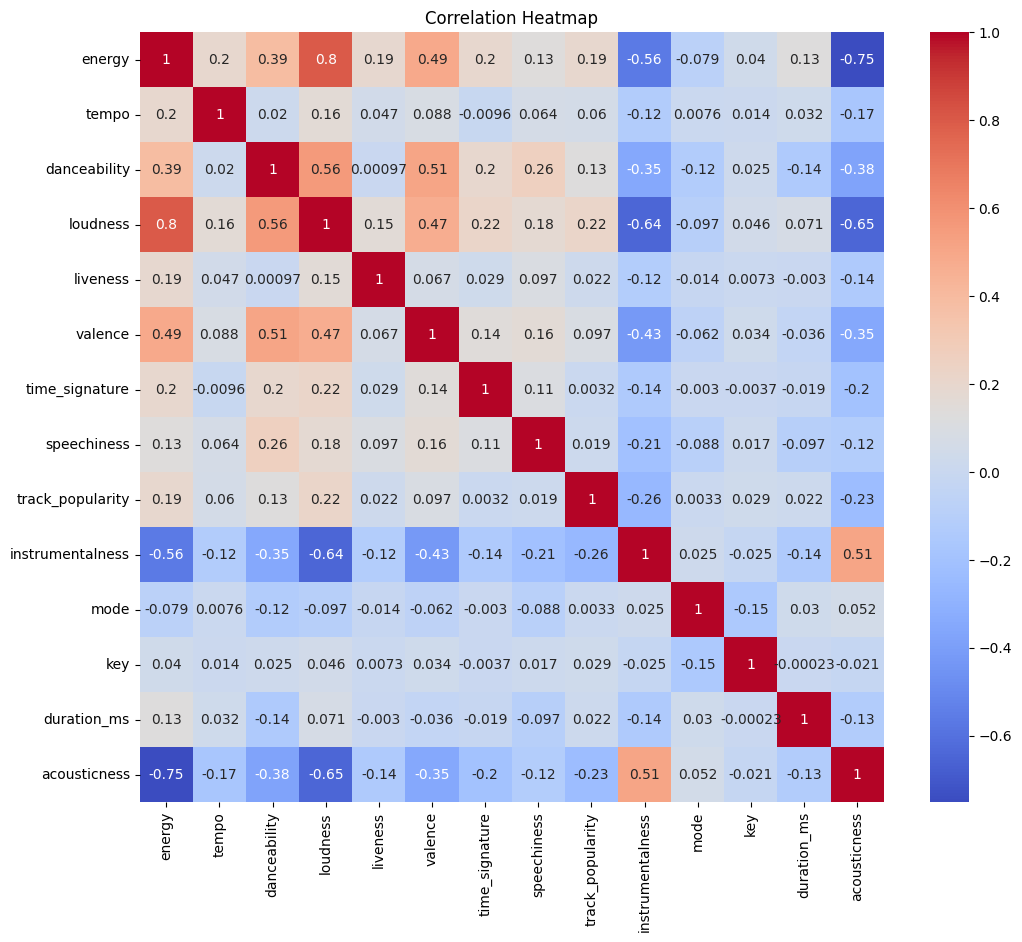

In [ ]:
# Correlation heatmap for numeric features
numeric_cols = combined_df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
sns.heatmap(combined_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

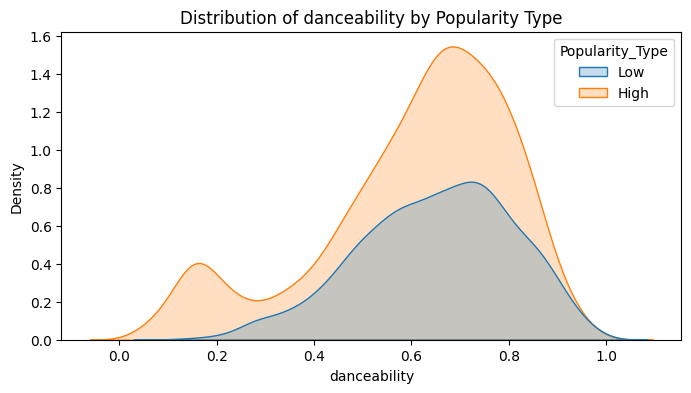

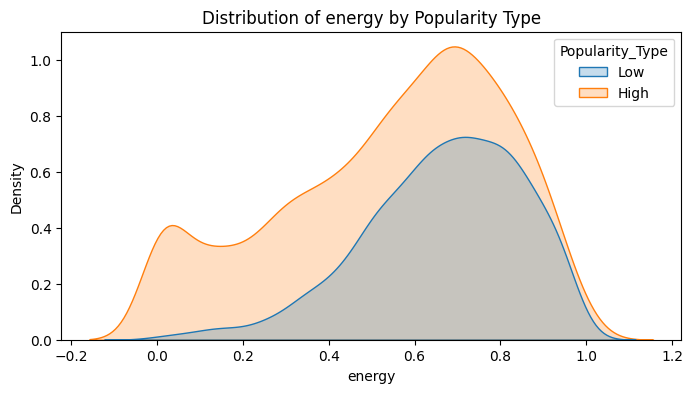

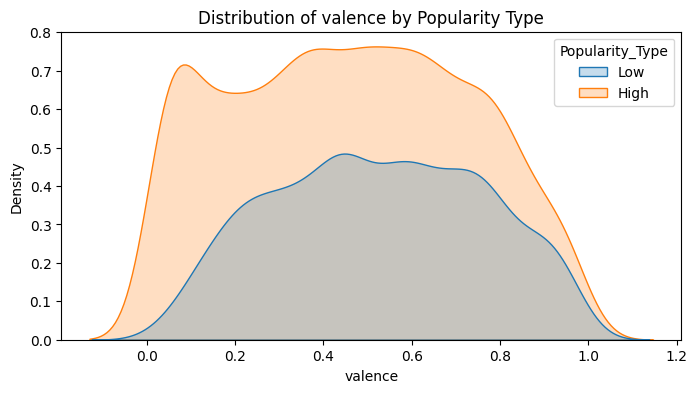

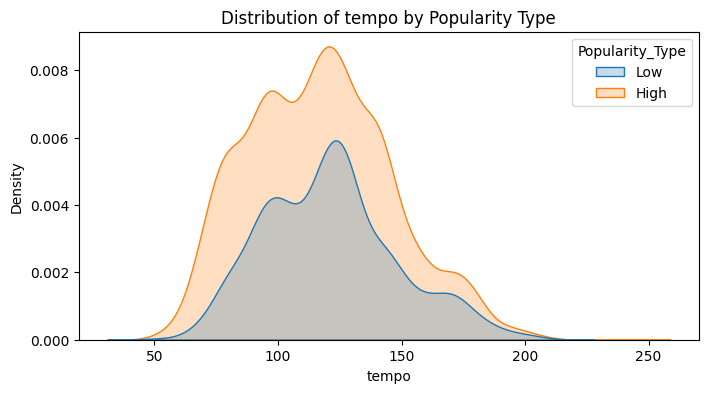

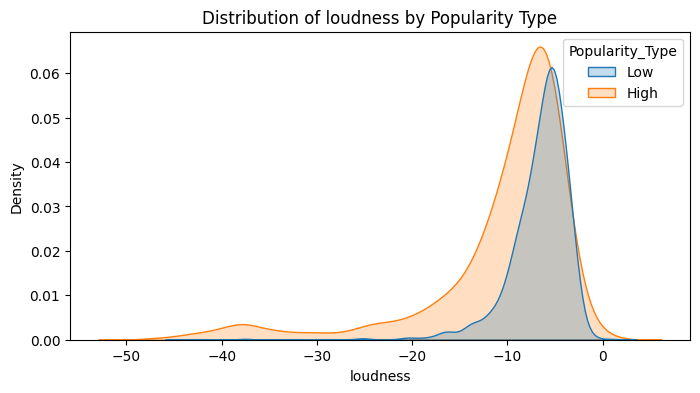

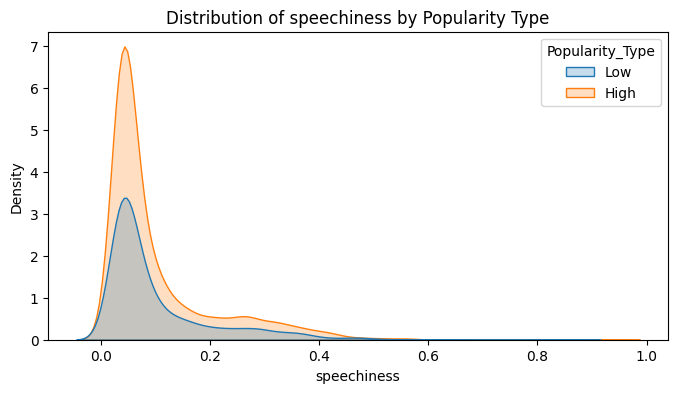

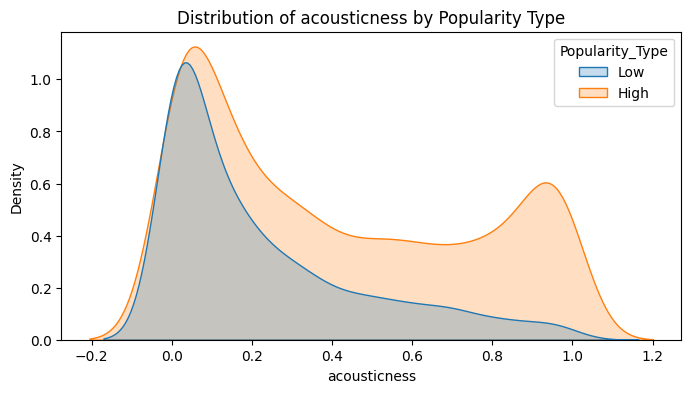

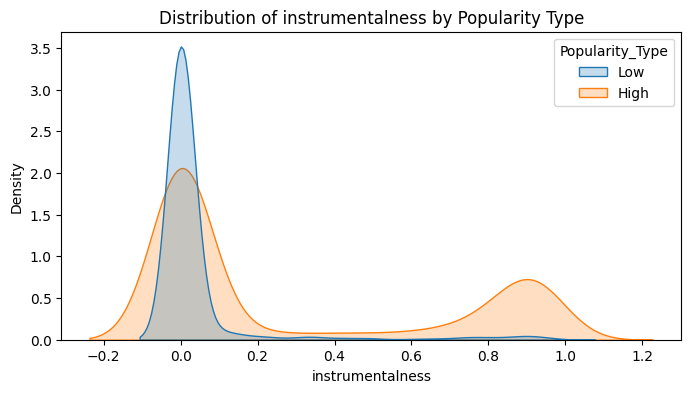

In [ ]:
# Distribution of audio features by popularity type
audio_features = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'acousticness', 'instrumentalness']
for feature in audio_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=combined_df, x=feature, hue='Popularity_Type', fill=True)
    plt.title(f'Distribution of {feature} by Popularity Type')
    plt.show()

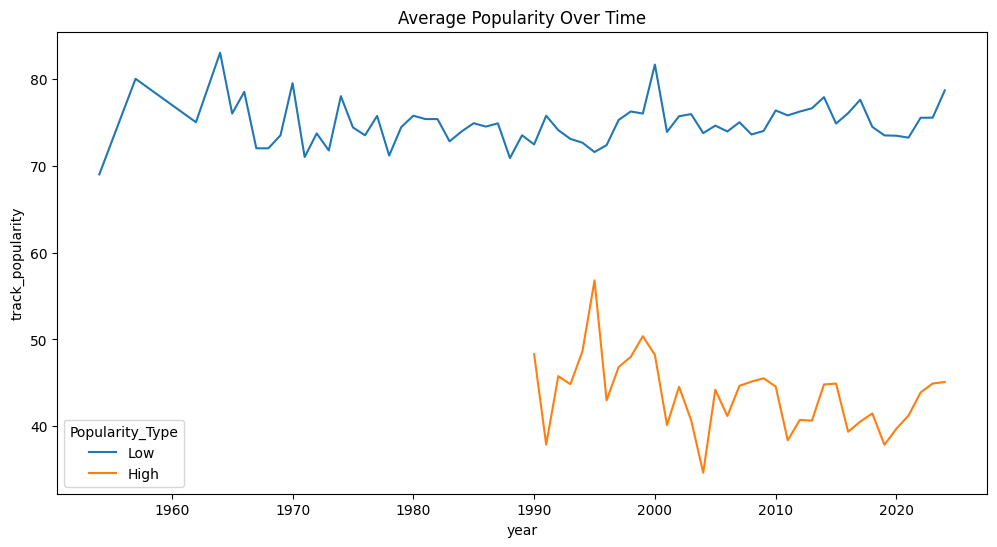

In [ ]:
# Popularity trends over time
combined_df['year'] = combined_df['track_album_release_date'].dt.year
popularity_trend = combined_df.groupby(['year', 'Popularity_Type'])['track_popularity'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=popularity_trend, x='year', y='track_popularity', hue='Popularity_Type')
plt.title('Average Popularity Over Time')
plt.show()

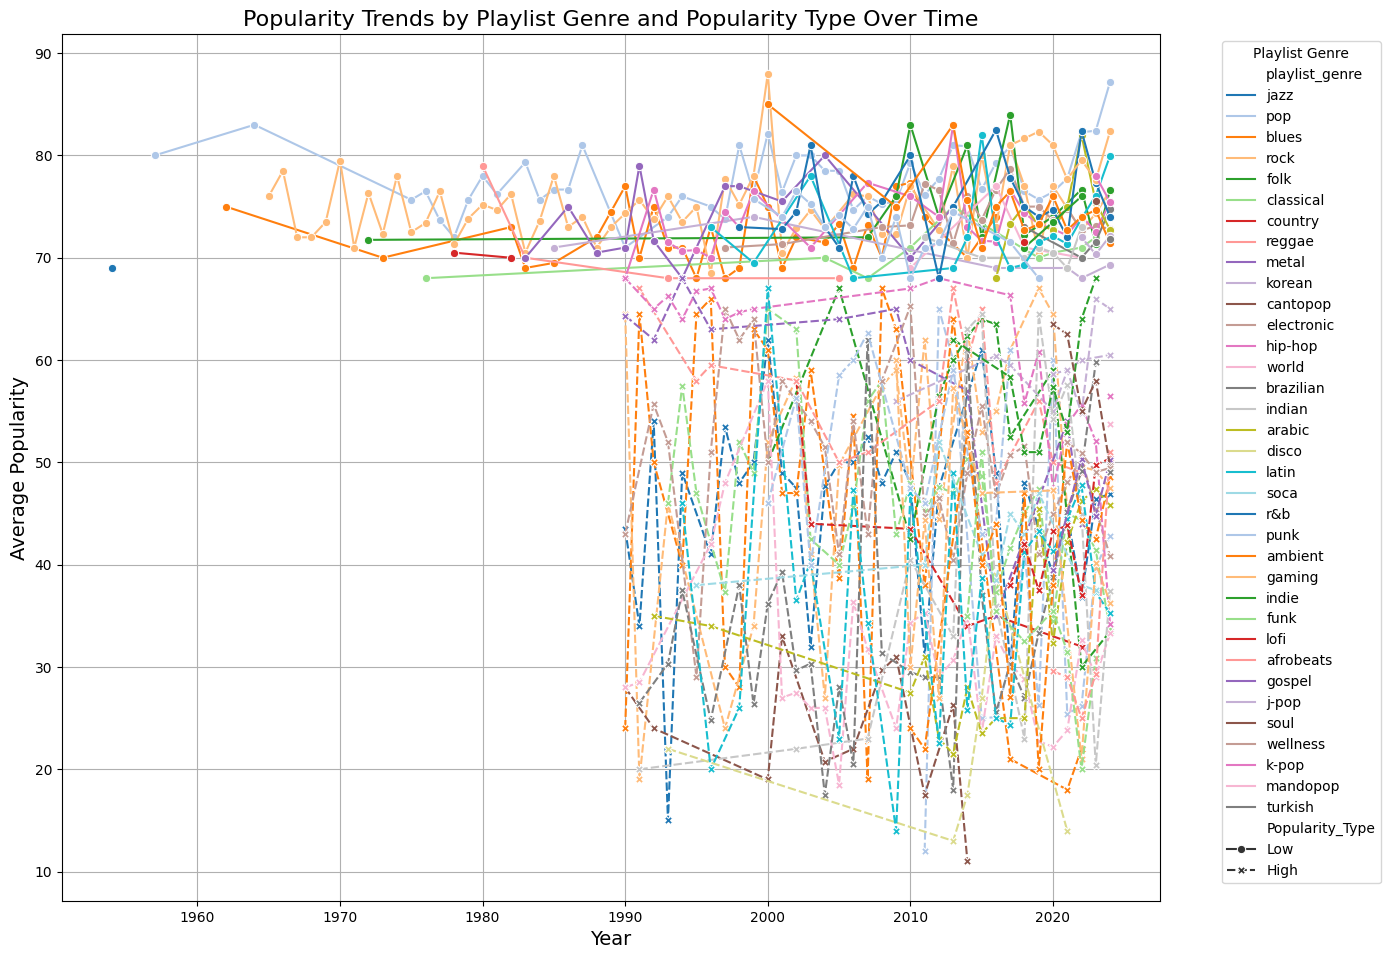

In [ ]:
# Group data by year, playlist genre, and popularity type to calculate average popularity
popularity_trends = (
    combined_df.groupby(['year', 'playlist_genre', 'Popularity_Type'])['track_popularity']
    .mean()
    .reset_index()
)

# Plot popularity trends
plt.figure(figsize=(14, 10))
sns.lineplot(
    data=popularity_trends,
    x='year',
    y='track_popularity',
    hue='playlist_genre',
    style='Popularity_Type',
    markers=True,
    dashes=True,
    palette='tab20'
)

# Add title and labels
plt.title('Popularity Trends by Playlist Genre and Popularity Type Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Popularity', fontsize=14)
plt.legend(title='Playlist Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Group by year and genre, calculate average popularity
genre_popularity = (combined_df.groupby(['year', 'playlist_genre'])['track_popularity'].mean().reset_index())

# Find the most and least popular genre per year
most_popular_genres = genre_popularity.loc[genre_popularity.groupby('year')['track_popularity'].idxmax()]
least_popular_genres = genre_popularity.loc[genre_popularity.groupby('year')['track_popularity'].idxmin()]

# Merge results for better comparison
popularity_summary = pd.merge(
    most_popular_genres,
    least_popular_genres,
    on='year',
    suffixes=('_most', '_least')
)

# Display the result
print(popularity_summary)

    year playlist_genre_most  track_popularity_most playlist_genre_least  \
0   1954                jazz              69.000000                 jazz   
1   1957                 pop              80.000000                  pop   
2   1962               blues              75.000000                blues   
3   1964                 pop              83.000000                  pop   
4   1965                rock              76.000000                 rock   
..   ...                 ...                    ...                  ...   
59  2020                 r&b              74.666667                world   
60  2021              gaming              77.666667                disco   
61  2022                 r&b              82.400000                 funk   
62  2023               k-pop              78.000000               indian   
63  2024                 pop              77.103093                world   

    track_popularity_least  
0                69.000000  
1                80.000000  


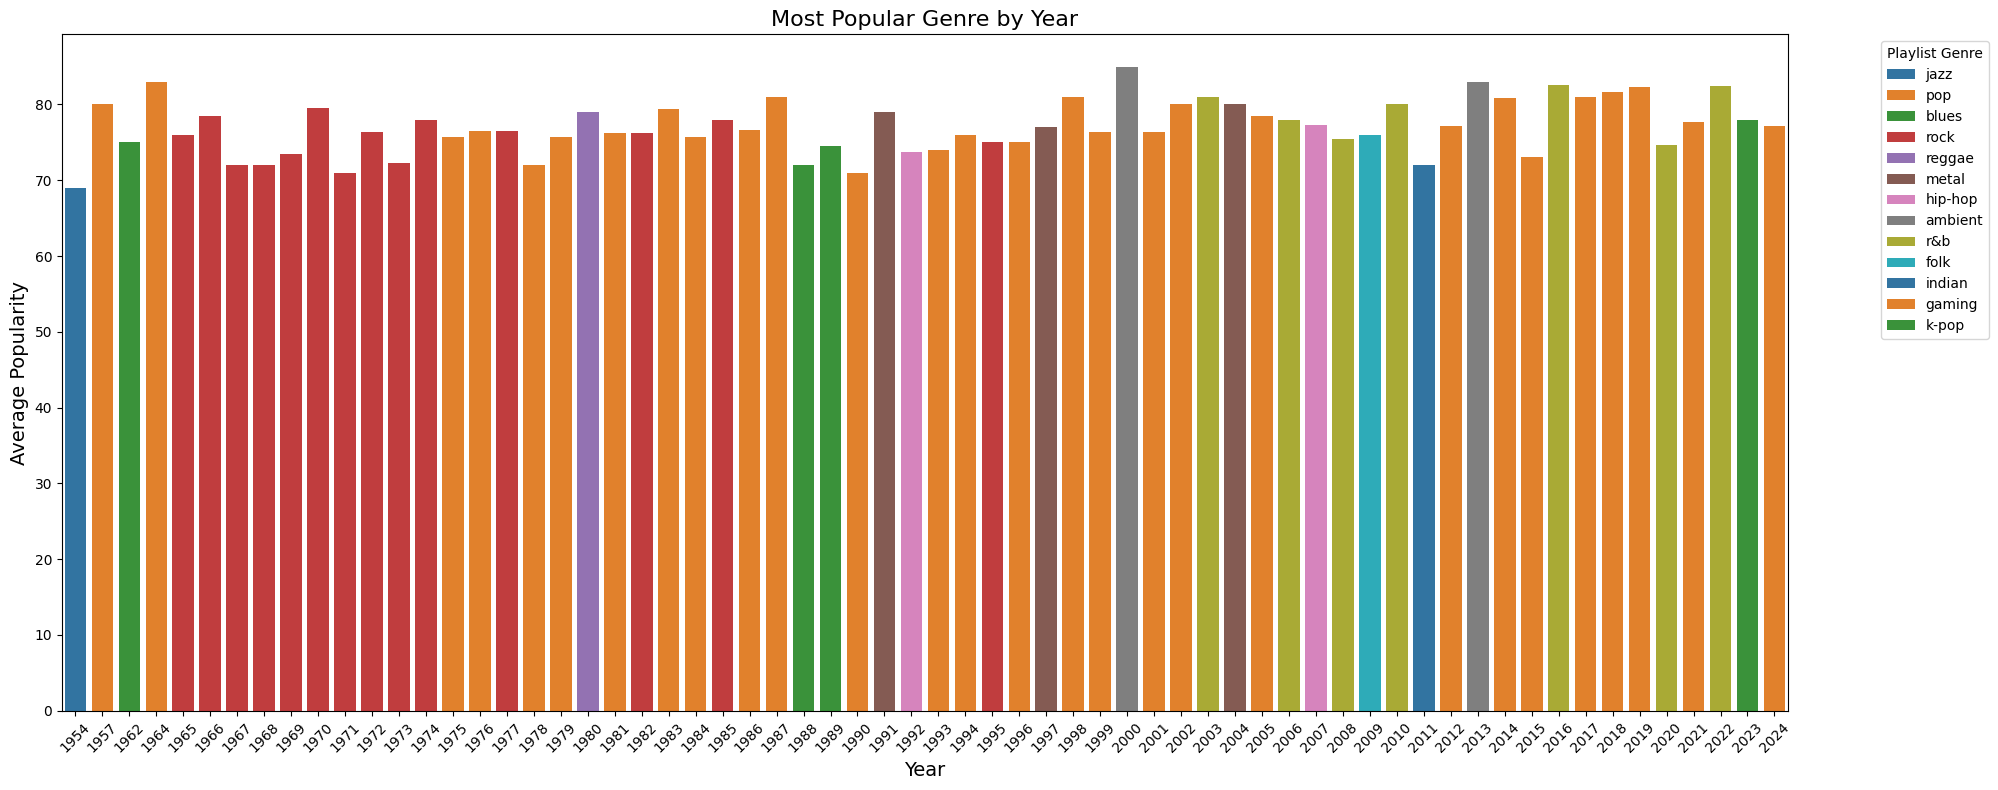

In [ ]:
# Plot the most popular genres over time
plt.figure(figsize=(20, 8))
sns.barplot(
    data=most_popular_genres,
    x='year',
    y='track_popularity',
    hue='playlist_genre',
    dodge=False,
    palette='tab10'
)
plt.title('Most Popular Genre by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Popularity', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Playlist Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

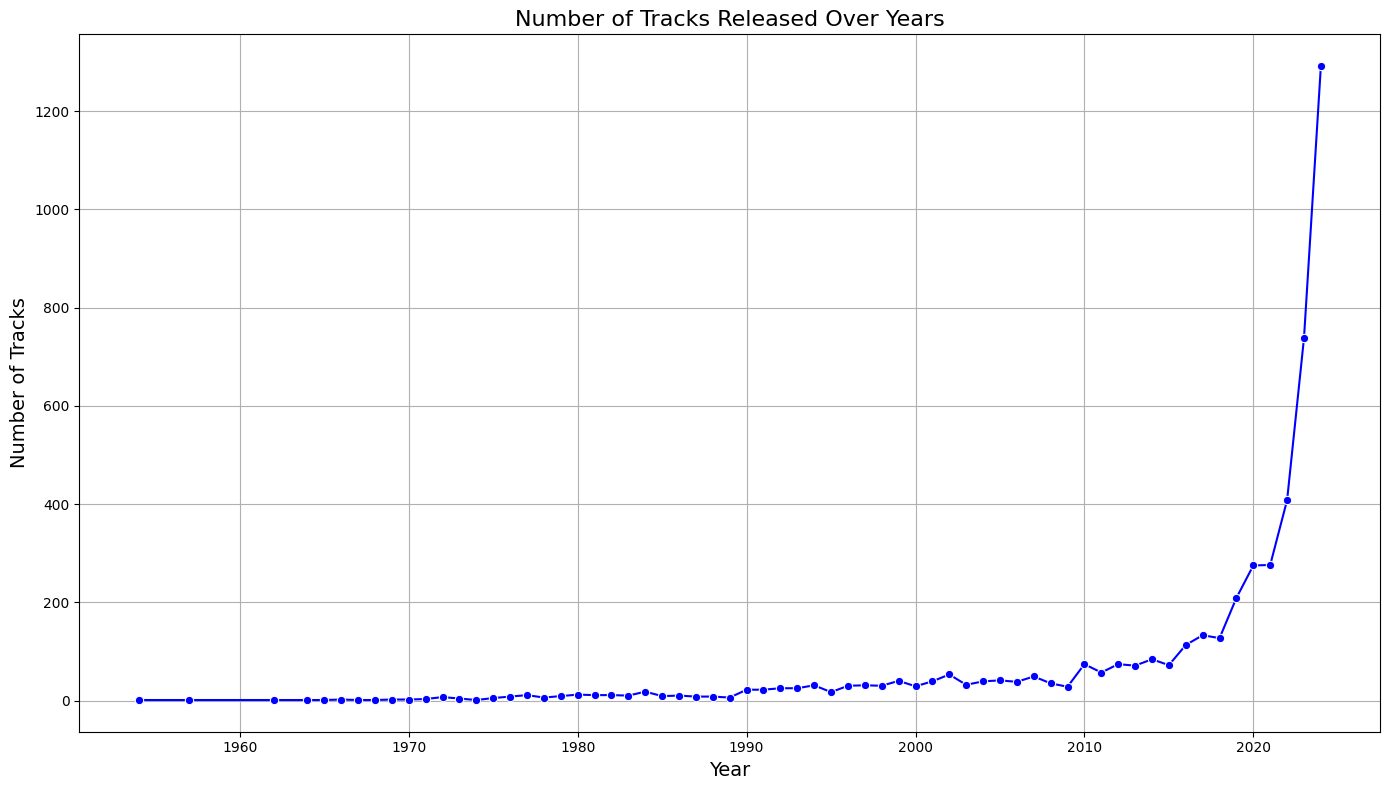

In [ ]:
# Count the number of tracks released per year
tracks_per_year = combined_df.groupby('year').size().reset_index(name='track_count')

# Plot the number of tracks released over years
plt.figure(figsize=(14, 8))
sns.lineplot(data=tracks_per_year, x='year', y='track_count', marker='o', color='blue')
plt.title('Number of Tracks Released Over Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Tracks', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

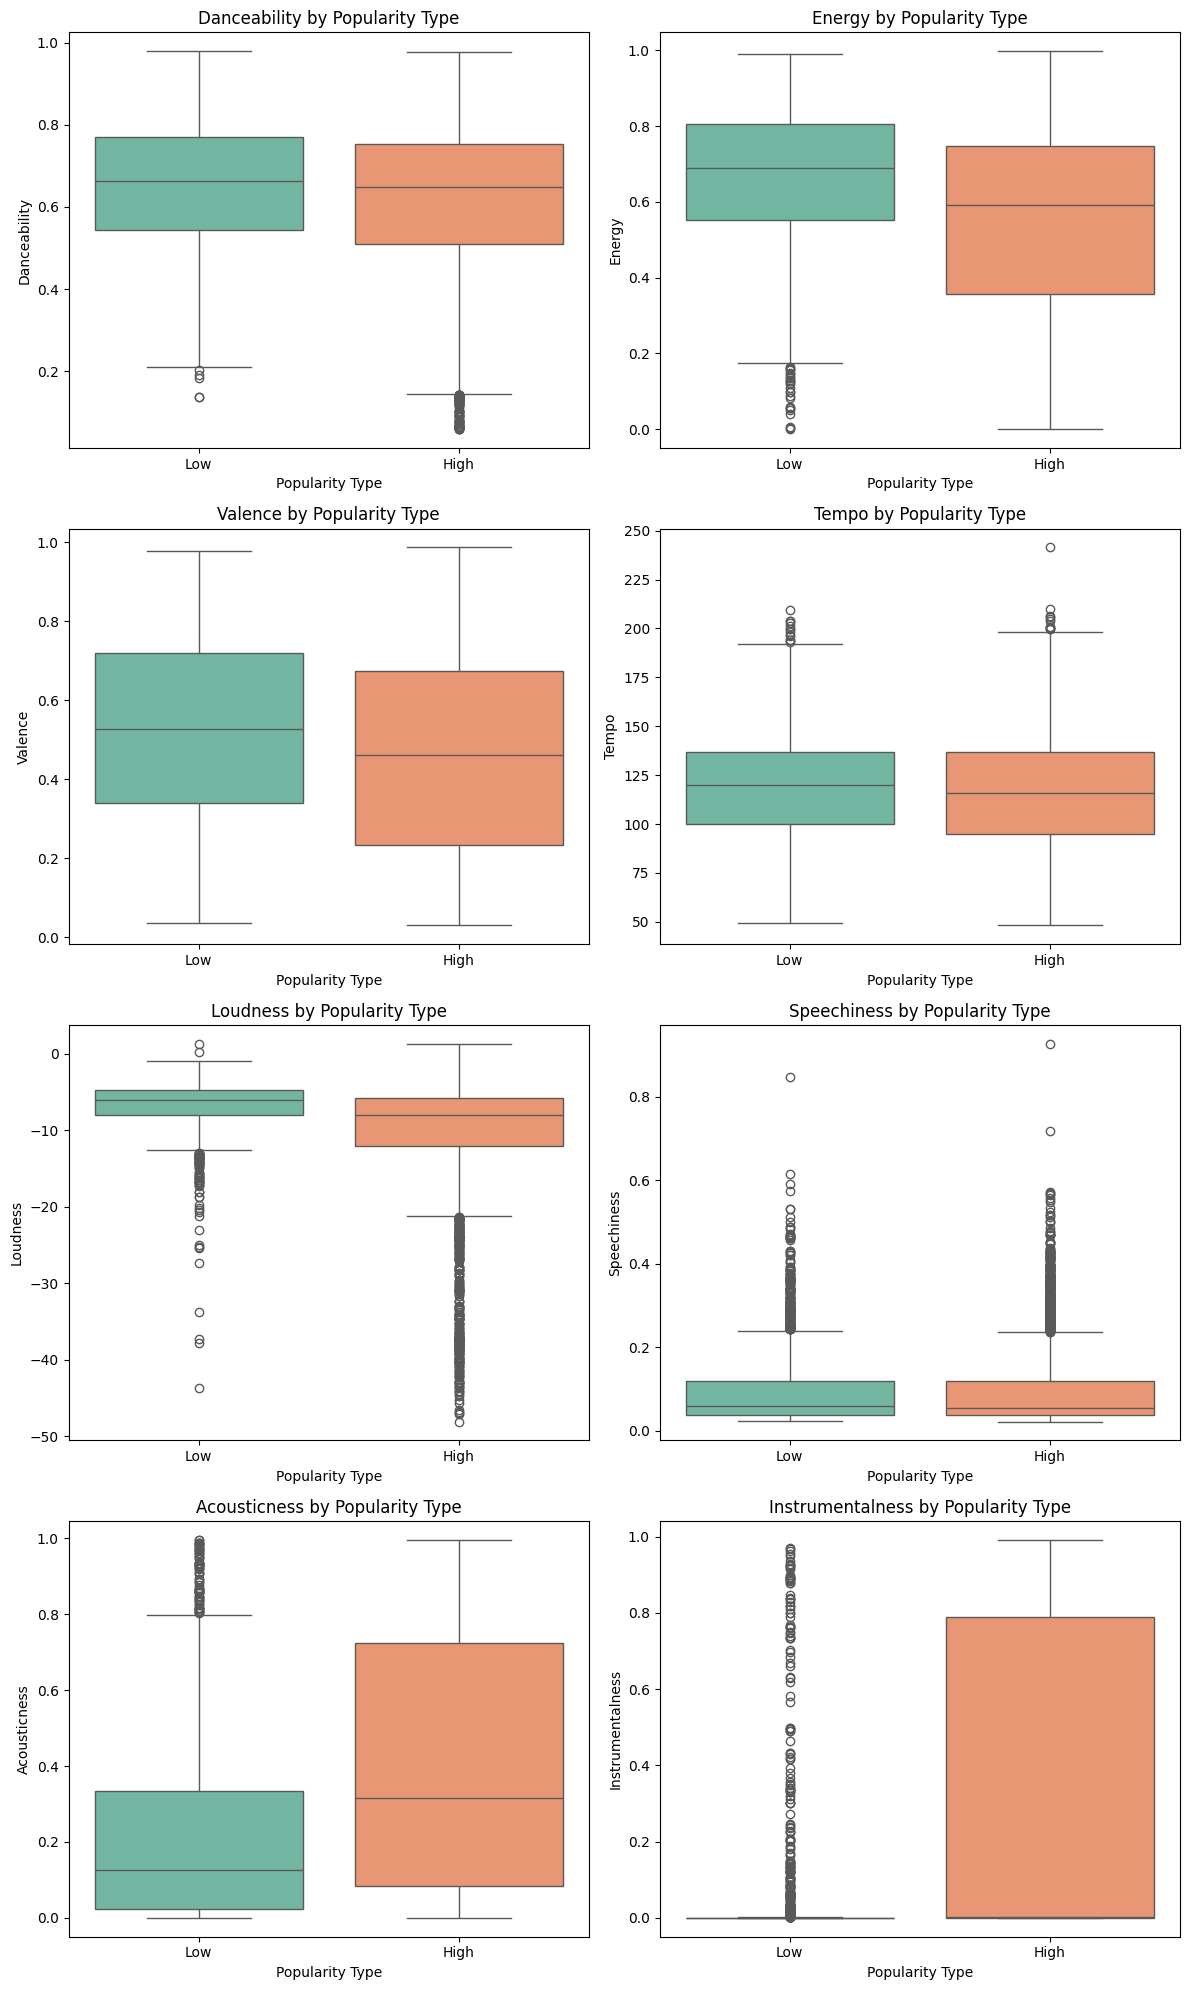

In [ ]:
plt.figure(figsize=(12, 20))
for i, feature in enumerate(audio_features):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(data=combined_df, x='Popularity_Type', y=feature, hue='Popularity_Type', palette='Set2')
    plt.title(f'{feature.capitalize()} by Popularity Type')
    plt.xlabel('Popularity Type')
    plt.ylabel(feature.capitalize())

plt.tight_layout()
plt.show()

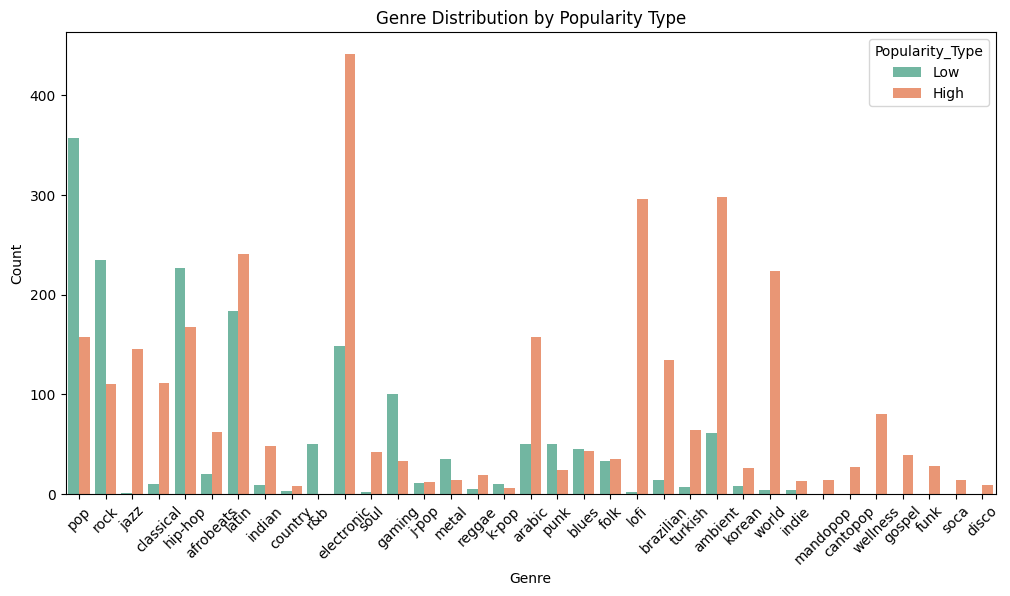

In [ ]:
# Count plot for genres by popularity type
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_df, x='playlist_genre', hue='Popularity_Type', palette='Set2')
plt.title('Genre Distribution by Popularity Type')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

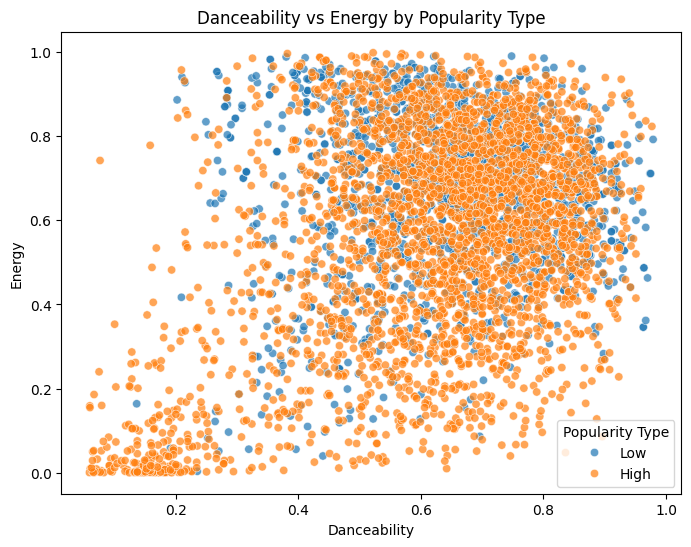

In [ ]:
# Scatter plot for danceability vs energy
plt.figure(figsize=(8, 6))
sns.scatterplot(data=combined_df, x='danceability', y='energy', hue='Popularity_Type', alpha=0.7)
plt.title('Danceability vs Energy by Popularity Type')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.legend(title='Popularity Type')
plt.show()

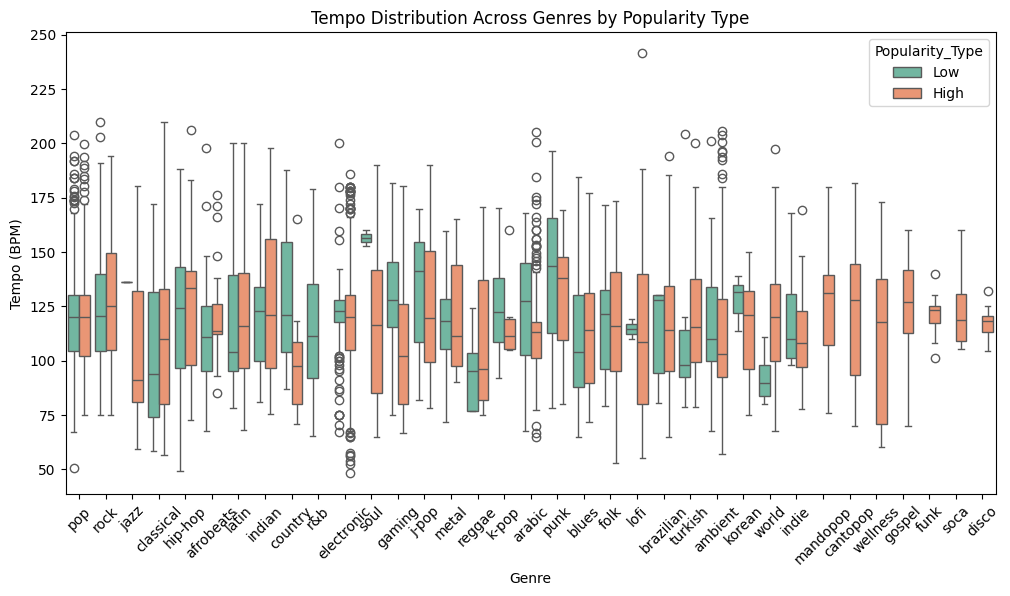

In [ ]:
# Boxplot for tempo across genres
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_df, x='playlist_genre', y='tempo', hue='Popularity_Type', palette='Set2')
plt.title('Tempo Distribution Across Genres by Popularity Type')
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.xticks(rotation=45)
plt.show()

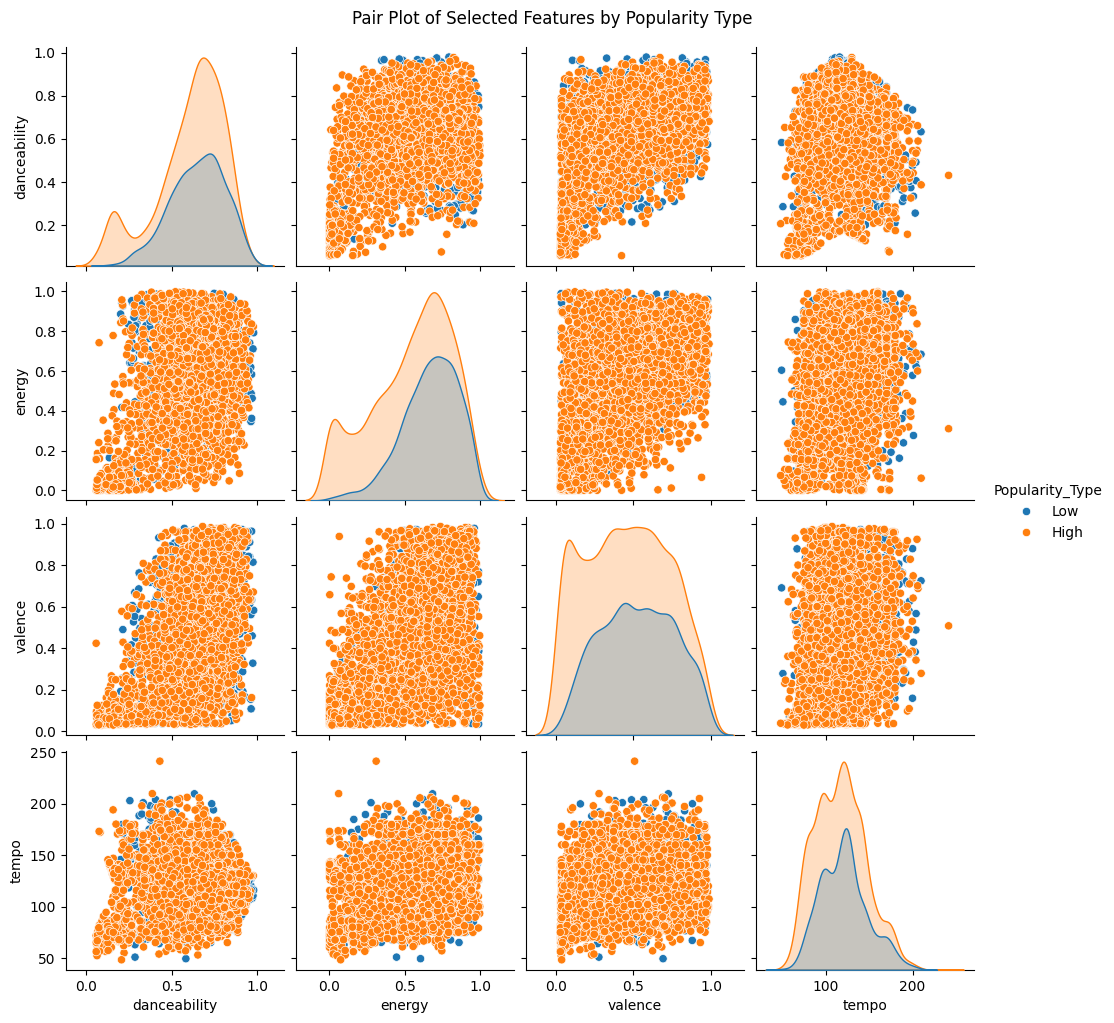

In [ ]:
# Select a subset of numerical features
selected_features = ['danceability', 'energy', 'valence', 'tempo']
sns.pairplot(combined_df[selected_features + ['Popularity_Type']], hue='Popularity_Type', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features by Popularity Type', y=1.02)
plt.show()

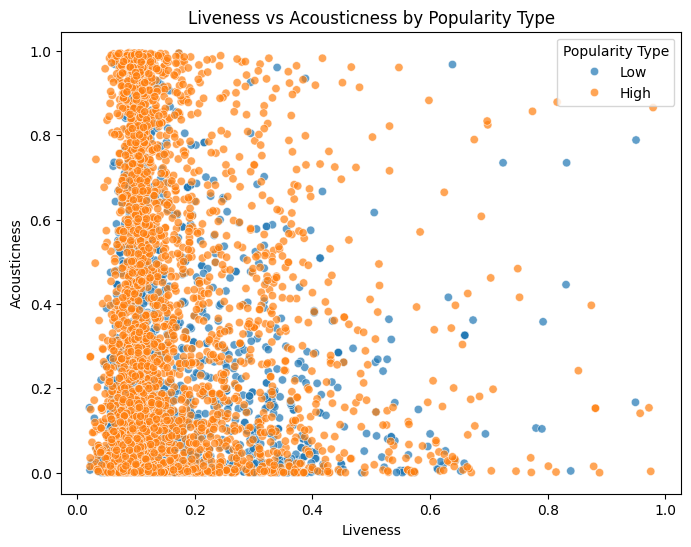

In [ ]:
# Scatter plot for liveness vs acousticness
plt.figure(figsize=(8, 6))
sns.scatterplot(data=combined_df, x='liveness', y='acousticness', hue='Popularity_Type', alpha=0.7)
plt.title('Liveness vs Acousticness by Popularity Type')
plt.xlabel('Liveness')
plt.ylabel('Acousticness')
plt.legend(title='Popularity Type')
plt.show()

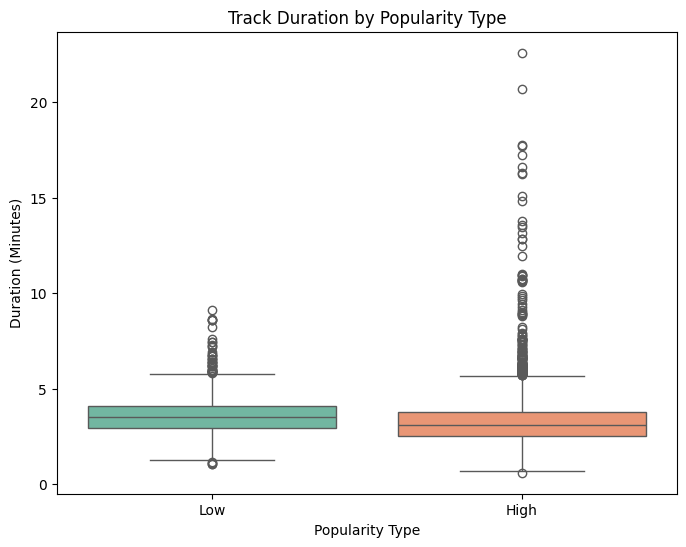

In [ ]:
# Convert duration from milliseconds to minutes
combined_df['duration_min'] = combined_df['duration_ms'] / 60000

# Boxplot for duration in minutes by popularity type
plt.figure(figsize=(8, 6))
sns.boxplot(data=combined_df, x='Popularity_Type', y='duration_min', hue='Popularity_Type', palette='Set2')
plt.title('Track Duration by Popularity Type')
plt.xlabel('Popularity Type')
plt.ylabel('Duration (Minutes)')
plt.show()

In [ ]:
combined_df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,mode,key,duration_ms,acousticness,playlist_subgenre,type,playlist_id,Popularity_Type,year,duration_min
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,0.0,6.0,251668.0,0.3080,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low,2024,4.194467
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,1.0,2.0,210373.0,0.2000,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low,2024,3.506217
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,1.0,1.0,166300.0,0.2140,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low,2024,2.771667
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,0.0,0.0,157280.0,0.0939,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low,2024,2.621333
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,0.0,0.0,169917.0,0.0283,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,Low,2024,2.831950


In [ ]:
# Extract year from the release date
combined_df['release_year'] = combined_df['track_album_release_date'].dt.year

# Create a new feature: Song Age (current year - release year)
current_year = 2025  # Using the current year from the given date
combined_df['song_age'] = current_year - combined_df['release_year']

# Create interaction features
combined_df['energy_danceability_ratio'] = combined_df['energy'] / (combined_df['danceability'] + 1e-5)
combined_df['valence_energy_product'] = combined_df['valence'] * combined_df['energy']

# Create a binary feature for whether the track is from the 2000s or earlier
combined_df['is_2000s_or_earlier'] = (combined_df['release_year'] <= 2000).astype(int)

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                      'instrumentalness', 'liveness', 'valence', 'tempo', 'song_age']
combined_df[numerical_features] = scaler.fit_transform(combined_df[numerical_features])

# Drop rows with missing values after feature engineering
combined_df = combined_df.dropna()

# Save the engineered dataset for modeling
combined_df.to_csv('engineered_spotify_data.csv', index=False)

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import files

# Load the engineered dataset
df = pd.read_csv('engineered_spotify_data.csv')

# Convert the target variable ('Popularity_Type') to numeric
df['Popularity_Type'] = df['Popularity_Type'].map({'High': 1, 'Low': 0})

# Identify non-numeric columns
non_numeric_columns = df.select_dtypes(exclude=[np.number]).columns

# Encode categorical variables
le = LabelEncoder()
for col in non_numeric_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Prepare features and target variable
X = df.drop(['Popularity_Type', 'track_album_release_date'], axis=1)
y = df['Popularity_Type']

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the SVM model with linear kernel
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svc.predict(X_test)

# Compute accuracy
svc_acc = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print('Akurasi SVM : {:.2f}%'.format(svc_acc * 100))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       358
           1       1.00      0.98      0.99       608

    accuracy                           0.98       966
   macro avg       0.98      0.99      0.98       966
weighted avg       0.98      0.98      0.98       966

Akurasi SVM : 98.34%


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       358
           1       1.00      0.98      0.99       608

    accuracy                           0.98       966
   macro avg       0.98      0.99      0.98       966
weighted avg       0.98      0.98      0.98       966

Akurasi SVM : 98.34%


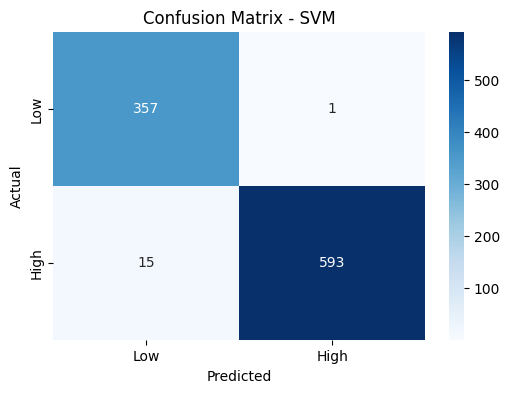

In [ ]:
# Make predictions on the test set
y_pred = svc.predict(X_test)

# Compute accuracy
svc_acc = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print('Akurasi SVM : {:.2f}%'.format(svc_acc * 100))

# ===== Tambahan: Visualisasi Confusion Matrix =====
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()